# Replicate: Nvidia AI IOT NanoSAM
### .onnx (onnxruntime-gpu)
July 29th

NanoSAM is a Segment Anything (SAM) model variant that is capable of running in 🔥 real-time 🔥 on NVIDIA Jetson Orin Platforms with NVIDIA TensorRT.

In [1]:
"""
# clean env wipe & activate
conda env remove --name nanosam_arm64 -y
conda deactivate
conda create -n nanosam_arm64 python=3.10 -y
conda activate nanosam_arm64

sudo apt update
sudo apt install libcudnn8 libcudnn8-dev
conda install -c conda-forge libstdcxx-ng=12 -y

"""

'\n# clean env wipe & activate\nconda env remove --name nanosam_arm64 -y\nconda deactivate\nconda create -n nanosam_arm64 python=3.10 -y\nconda activate nanosam_arm64\n\nsudo apt update\nsudo apt install libcudnn8 libcudnn8-dev\nconda install -c conda-forge libstdcxx-ng=12 -y\n\n'

In [2]:
"""
# Installation of nanosam_arm64 repo requirements

git clone https://github.com/NVIDIA-AI-IOT/nanosam
cd nanosam
python3 setup.py develop --user


# More requirements
pip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 'opencv-python<4.9' jetson-stats


# Typical np version mismatch
pip uninstall -y numpy
pip install "numpy>=1.19.2,<2.0"
# pip install numpy==1.26.4 

# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)
pip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl

# download torchvision 0.20.0a0 (compatible with jp61 torch)
cd ~/vision/
python3 setup.py install
cd ~

# --- ONNXRUNTIME-GPU (build from scratch) ------------- #

cd ~/onnxruntime
pip uninstall onnxruntime -y
pip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall
pip install sympy==1.13.1 numpy==1.26.4

"""

# Debug Support

# Check your conda env GLIBCXX versions
# strings /home/copter/miniconda3/envs/nanosam_arm64/lib/python3.10/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6 | grep GLIBCXX

# trt2torch is apparently an issue and is obsolete for trt --version=10.3.0 
# additionally `pip install pycuda`

'\n# Installation of nanosam_arm64 repo requirements\n\ngit clone https://github.com/NVIDIA-AI-IOT/nanosam\ncd nanosam\npython3 setup.py develop --user\n\n\n# More requirements\npip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 \'opencv-python<4.9\' jetson-stats\n\n\n# Typical np version mismatch\npip uninstall -y numpy\npip install "numpy>=1.19.2,<2.0"\n# pip install numpy==1.26.4 \n\n# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)\npip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl\n\n# download torchvision 0.20.0a0 (compatible with jp61 torch)\ncd ~/vision/\npython3 setup.py install\ncd ~\n\n# --- ONNXRUNTIME-GPU (build from scratch) ------------- #\n\ncd ~/onnxruntime\npip uninstall onnxruntime -y\npip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall\npip install sympy==1.13.1 numpy==1.26.4\n\n'

In [ ]:
# from nanosam.utils.predictor import Predictor
import onnxruntime as ort
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


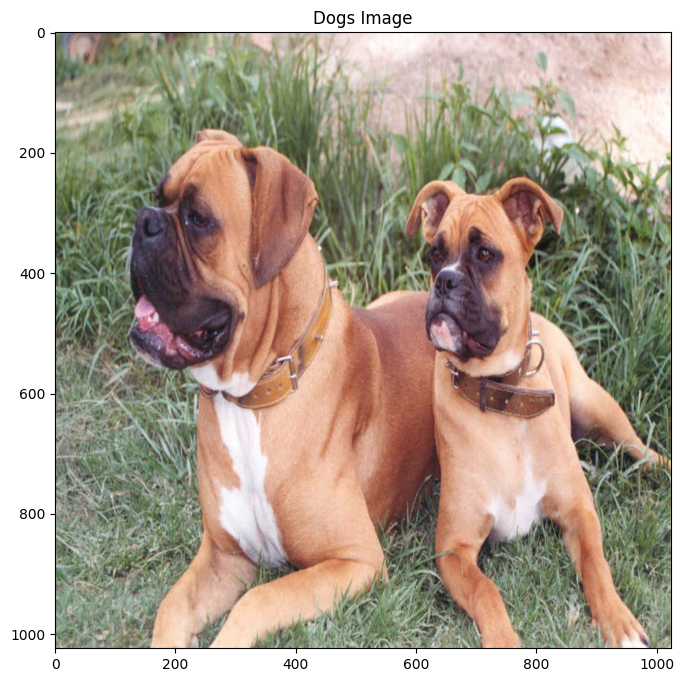

In [28]:
# Load the image
# image = PIL.open("/home/copter/jetson_benchmark/images/dogs.jpg")
image_path = "/home/copter/jetson_benchmark/images/dogs.jpg"
img = Image.open(image_path).convert("RGB")
img = img.resize((1024, 1024), resample=Image.BILINEAR)
w, h = img.size  # now both are 1024

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('on')  # Hide axes for cleaner display
plt.title("Dogs Image")
plt.show()

In [5]:
encoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_resnet18_image_encoder.onnx"
decoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_mobile_sam_mask_decoder.onnx"

In [6]:
### Check available Execution Providers

print("--- Checking Available Execution Providers ---")
available_providers = ort.get_available_providers()
print(f"Available ONNX Runtime Execution Providers: {available_providers}")

# Check for specific providers
has_tensorrt = 'TensorrtExecutionProvider' in available_providers
has_cuda = 'CUDAExecutionProvider' in available_providers
has_cpu = 'CPUExecutionProvider' in available_providers

print(f"\nTensorRT Execution Provider available: {has_tensorrt}")
print(f"CUDA Execution Provider available: {has_cuda}")
print(f"CPU Execution Provider available: {has_cpu}")

--- Checking Available Execution Providers ---
Available ONNX Runtime Execution Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

TensorRT Execution Provider available: True
CUDA Execution Provider available: True
CPU Execution Provider available: True


In [7]:
preferred_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

try:
    print(f"Attempting to load encoder model with providers: {preferred_providers}")
    enc_sess = ort.InferenceSession(encoder_model_path, providers=preferred_providers)
    print(f"Encoder session loaded. Actual provider used: {enc_sess.get_providers()}")

    print(f"Attempting to load decoder model with providers: {preferred_providers}")
    dec_sess = ort.InferenceSession(decoder_model_path, providers=preferred_providers)
    print(f"Decoder session loaded. Actual provider used: {dec_sess.get_providers()}")

    # Verify which provider was actually chosen by ONNX Runtime
    if 'TensorrtExecutionProvider' in enc_sess.get_providers() and \
       'TensorrtExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.")
    elif 'CUDAExecutionProvider' in enc_sess.get_providers() and \
         'CUDAExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider (TensorRT not available or failed).")
    else:
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")

except Exception as e:
    print(f"An error occurred during session creation with preferred providers: {e}")
    # Fallback to CPU if preferred providers fail entirely
    print("Falling back to CPUExecutionProvider for both models.")
    try:
        enc_sess = ort.InferenceSession(encoder_model_path, providers=['CPUExecutionProvider'])
        dec_sess = ort.InferenceSession(decoder_model_path, providers=['CPUExecutionProvider'])
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider !!")
    except Exception as cpu_e:
        print(f"Fatal Error: Could not load models even with CPUExecutionProvider: {cpu_e}")

Attempting to load encoder model with providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Encoder session loaded. Actual provider used: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Attempting to load decoder model with providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Decoder session loaded. Actual provider used: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.


2025-07-31 14:18:38.794013232 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1794035, index: 2, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-07-31 14:18:38.798001441 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1794033, index: 0, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-07-31 14:18:38.799482742 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1794034, index: 1, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-07-31 14:20:43.307168905 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1794881, index: 0, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the

In [ ]:
import time
import numpy as np
import onnxruntime as ort # Changed import to 'ort' for brevity
from jtop import jtop
import gc
import os

# Initialize jtop before any models are loaded
try:
    jetson = jtop()
    jetson.start()
    print("jtop started and ready for memory monitoring.")
except Exception as e:
    print(f"Could not start jtop: {e}. Running without memory monitoring.")
    jetson = None


def load_models_and_get_memory_footprint(enc_path, dec_path, execution_providers):
    """
    Loads both encoder and decoder models and returns the memory footprint.
    
    This version includes SessionOptions to explicitly set thread counts,
    which resolves the "pthread_setaffinity_np failed" errors.
    """
    # execution_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
    enc_sess = None
    dec_sess = None
    
    # Define session options to prevent "pthread_setaffinity_np failed" errors
    # by explicitly setting the number of threads.
    options = ort.SessionOptions()
    options.intra_op_num_threads = os.cpu_count() or 4
    options.inter_op_num_threads = os.cpu_count() or 4
    
    try:
        print(f"\nLoading models from path: {enc_path} and {dec_path}")
        enc_sess = ort.InferenceSession(enc_path, providers=execution_providers, sess_options=options)
        print(f"Encoder session loaded. Provider: {enc_sess.get_providers()}")

        dec_sess = ort.InferenceSession(dec_path, providers=execution_providers, sess_options=options)
        print(f"Decoder session loaded. Provider: {dec_sess.get_providers()}")

        # Verify which provider was actually chosen by ONNX Runtime
        if 'TensorrtExecutionProvider' in enc_sess.get_providers() and \
        'TensorrtExecutionProvider' in dec_sess.get_providers():
            print("✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.")
        elif 'CUDAExecutionProvider' in enc_sess.get_providers() and \
            'CUDAExecutionProvider' in dec_sess.get_providers():
            print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider (TensorRT not available or failed).")
        else:
            print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")

        if jetson:
            # Capture memory right after models are loaded
            loaded_memory = jetson.memory['RAM']['used'] / (1024**3) # in GB
            print(f"-> Memory after models loaded: {loaded_memory:.2f} GB ({loaded_memory * 1024:.2f} MB)")
            return enc_sess, dec_sess, loaded_memory
        else:
            return enc_sess, dec_sess, None

    except Exception as e:
        print(f"An error occurred during session creation: {e}")
        # Fallback to CPU if preferred providers fail entirely
        print("Falling back to CPUExecutionProvider for both models.")
        try:
            # Note: The fallback also uses the new session options
            enc_sess = ort.InferenceSession(enc_path, providers=['CPUExecutionProvider'], sess_options=options)
            dec_sess = ort.InferenceSession(dec_path, providers=['CPUExecutionProvider'], sess_options=options)
            print("-> ⚠️ Models loaded successfully with CPUExecutionProvider.")
            if jetson:
                loaded_memory = jetson.memory['RAM']['used'] / (1024**3) # in GB
                print(f"-> Memory after models loaded: {loaded_memory:.2f} GB ({loaded_memory * 1024:.2f} MB)")
                return enc_sess, dec_sess, loaded_memory
            else:
                return enc_sess, dec_sess, None
        except Exception as cpu_e:
            print(f"Fatal Error: Could not load models even with CPUExecutionProvider: {cpu_e}")
            if jetson: jetson.close()
            exit()


def unload_models_and_release_memory(enc_sess, dec_sess):
    """
    Explicitly deletes model session objects and forces garbage collection.
    """
    print("\nAttempting to unload models and release memory...")
    
    # 1. Delete the session objects to remove references
    del enc_sess
    del dec_sess
    
    # 2. Trigger the garbage collector to reclaim the memory
    gc.collect()
    
    print("Models unloaded. Garbage collection triggered.")
    if jetson:
        current_memory = jetson.memory['RAM']['used'] / (1024**3)
        print(f"-> Memory after unloading models: {current_memory:.2f} GB ({current_memory * 1024:.2f} MB)")
        return current_memory
    return None


jtop started and ready for memory monitoring.


In [ ]:
# --- Load Models 1st Time and Measure Memory ---
execution_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

initial_enc_sess, initial_dec_sess, initial_memory = load_models_and_get_memory_footprint(encoder_model_path, decoder_model_path, execution_providers)

# --- Unload Models and Release Memory ---
print("\n--- Now unloading models and releasing memory ---")
memory_after_unload = unload_models_and_release_memory(initial_enc_sess, initial_dec_sess)

# --- Load Models 2nd Time and Measure Memory ---
print("\n--- Now loading a new model instance ---")
enc_sess, dec_sess, new_memory = load_models_and_get_memory_footprint(encoder_model_path, decoder_model_path)

if jetson:
    memory_change = new_memory - (memory_after_unload if memory_after_unload is not None else 0)
    print(f"\nMemory allocated for the new model instance: {memory_change:.2f} GB")
    print("This value should be very close to the memory taken by the initial load.")

# Final cleanup
if jetson:
    jetson.close()
    print("\njtop closed.")


Loading models from path: /home/copter/onnx_models/nvidia_ai_iot_resnet18_image_encoder.onnx and /home/copter/onnx_models/nvidia_ai_iot_mobile_sam_mask_decoder.onnx
Encoder session loaded. Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


2025-07-31 14:43:28.880456950 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:531 RegisterTensorRTPluginsAsCustomOps] The custom op domain name trt.plugins is already in session option.


Decoder session loaded. Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
-> Memory after models loaded: 0.02 GB (19.91 MB)

--- Now unloading models and releasing memory ---

Attempting to unload models and release memory...
Models unloaded. Garbage collection triggered.
-> Memory after unloading models: 0.02 GB (19.91 MB)

--- Now loading a new model instance ---

Loading models from path: /home/copter/onnx_models/nvidia_ai_iot_resnet18_image_encoder.onnx and /home/copter/onnx_models/nvidia_ai_iot_mobile_sam_mask_decoder.onnx
Encoder session loaded. Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Decoder session loaded. Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
-> Memory after models loaded: 0.02 GB (19.91 MB)

Memory allocated for the new model instance: 0.00 GB
This value should be very close to the memory taken by the initial load.

jtop closed.


2025-07-31 14:45:32.320775487 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:531 RegisterTensorRTPluginsAsCustomOps] The custom op domain name trt.plugins is already in session option.


In [ ]:
# # --- Model Loading and Initial Memory Measurement ---
# preferred_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
# enc_sess = None
# dec_sess = None

# try:
#     print(f"Attempting to load encoder model with providers: {preferred_providers}")
#     enc_sess = ort.InferenceSession(encoder_model_path, providers=preferred_providers)
#     print(f"Encoder session loaded. Actual provider used: {enc_sess.get_providers()}")

#     print(f"Attempting to load decoder model with providers: {preferred_providers}")
#     dec_sess = ort.InferenceSession(decoder_model_path, providers=preferred_providers)
#     print(f"Decoder session loaded. Actual provider used: {dec_sess.get_providers()}")

#     # Verify which provider was actually chosen by ONNX Runtime
#     if 'TensorrtExecutionProvider' in enc_sess.get_providers() and \
#        'TensorrtExecutionProvider' in dec_sess.get_providers():
#         print("✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.")
#     elif 'CUDAExecutionProvider' in enc_sess.get_providers() and \
#          'CUDAExecutionProvider' in dec_sess.get_providers():
#         print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider (TensorRT not available or failed).")
#     else:
#         print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")

# except Exception as e:
#     print(f"An error occurred during session creation with preferred providers: {e}")
#     # Fallback to CPU if preferred providers fail entirely
#     print("Falling back to CPUExecutionProvider for both models.")
#     try:
#         enc_sess = ort.InferenceSession(encoder_model_path, providers=['CPUExecutionProvider'])
#         dec_sess = ort.InferenceSession(decoder_model_path, providers=['CPUExecutionProvider'])
#         print("⚠️ ONNX models loaded successfully with CPUExecutionProvider !!")
#     except Exception as cpu_e:
#         print(f"Fatal Error: Could not load models even with CPUExecutionProvider: {cpu_e}")
#         # Ensure jtop is closed even in case of fatal error
#         jetson.close()
#         print("\njtop closed...")
#         exit() # Exit if models cannot be loaded at all

# # Create a dummy image for demonstration (adjust dimensions if needed for your model)
# # Assuming typical SAM input dimensions
# h, w = 1024, 1024
# img = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)

# # Capture memory right after models are loaded
# loaded_models_memory = jetson.memory['RAM']['used'] / (1024**3) # in GB
# loaded_models_memory_mb = loaded_models_memory * 1024 # in MB

# print(f"\nMemory after models loaded (Encoder & Decoder): {loaded_models_memory:.2f} GB ({loaded_models_memory_mb:.2f} MB)")

In [ ]:
# ---- PRIMITIVE INFERENCE DEMO (in MS) ------------------------------- # 

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import onnxruntime as ort
import os

# 1) Inspect exactly which inputs the mask‐decoder wants:
for inp in dec_sess.get_inputs():
    print(inp.name, inp.shape, inp.type)

# 2) Normalize & transpose input image to NCHW
img_arr = np.array(img).astype(np.float32) / 255.0  # image --> arr
input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]     #  traspose arr

# ENCODER: Run the encoder (H, W are supposed to be 1024 x 1024)
enc_input_name = enc_sess.get_inputs()[0].name

# Produce image embeddings
image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

# 4) Assume image_embeddings is already float32
point_coords = np.array([[[w/2, h/2]]], dtype=np.float32)    # <-- Point Prompt: was already float32
point_labels = np.array([[1]],           dtype=np.float32)   # <-- Point labels, 1 = foreground, 0 = background

# dummy “previous mask” inputs must be float32
dummy_mask_input     = np.zeros((1, 1, 256, 256), dtype=np.float32)
dummy_has_mask_input = np.zeros((1,        ), dtype=np.float32)  # <— float32

# bundle by name
dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
dec_inputs = {
    dec_input_names[0]: image_embeddings,
    dec_input_names[1]: point_coords,
    dec_input_names[2]: point_labels,
    dec_input_names[3]: dummy_mask_input,
    dec_input_names[4]: dummy_has_mask_input,
}

# DECODE: Unpack mask outputs
mask_out, scores = dec_sess.run(None, dec_inputs)
print("Decoder outputs:")
for out in dec_sess.get_outputs():
    print(f"  {out.name}: {out.shape}")

# 2) Run and unpack correctly
raw_outs = dec_sess.run(None, dec_inputs)
# raw_outs[0].shape == (1, 4) → that's scores
# raw_outs[1].shape == (1, 4, 256, 256) → that's mask_out
scores, mask_out = raw_outs

# 3) Print shapes & count
print("mask_out shape:", mask_out.shape)   # should be (1, N, H, W)
print("scores   shape:", scores.shape)     # should be (1, N)
n_masks = mask_out.shape[1]
print("number of masks predicted:", n_masks)

image_embeddings [1, 256, 64, 64] tensor(float)
point_coords [1, 'num_points', 2] tensor(float)
point_labels [1, 'num_points'] tensor(float)
mask_input [1, 1, 256, 256] tensor(float)
has_mask_input [1] tensor(float)
Decoder outputs:
  iou_predictions: ['Gemmiou_predictions_dim_0', 4]
  low_res_masks: ['Reshapelow_res_masks_dim_0', 'Reshapelow_res_masks_dim_1', 'Reshapelow_res_masks_dim_2', 'Reshapelow_res_masks_dim_3']
mask_out shape: (1, 4, 256, 256)
scores   shape: (1, 4)
number of masks predicted: 4


Best mask idx: 2   score: 0.784


(-0.5, 1023.5, 1023.5, -0.5)

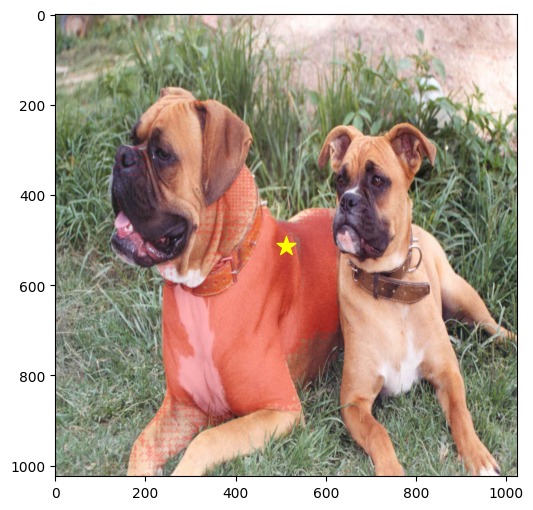

In [30]:
# ---- Mask Selection and Display ------------------------ #

# 1) Pick the best mask
scores_flat = scores.flatten()
best_idx    = int(np.argmax(scores_flat))
print(f"Best mask idx: {best_idx}   score: {scores_flat[best_idx]:.3f}")

# 2) Extract, threshold, and resize the mask
raw_mask  = mask_out[0, best_idx]            # (H_mask,W_mask) in [0,1]
binary    = (raw_mask > 0.5).astype(np.uint8) * 255
mask_img  = Image.fromarray(binary)
mask_rs   = mask_img.resize((w, h), Image.BILINEAR)

# 3) Build a 20%‑opaque red overlay
#    Take the 0–255 mask and scale it to 0–51 (≈20% of 255)
alpha_mask = mask_rs.point(lambda p: int(p * 0.3))
red_layer  = Image.new("RGBA", (w, h), (255, 0, 0, 0))
red_layer.putalpha(alpha_mask)

# 4) Composite over the original
base_rgba  = img.convert("RGBA")
composited = Image.alpha_composite(base_rgba, red_layer)

# 5) Plot with a star at the prompt point
star_x, star_y = point_coords[0, 0]
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(composited)
ax.scatter(star_x, star_y, marker="*", color="yellow", s=200)
ax.axis("on")


In [31]:
# ---- MAIN TIMING BENCH (in MS) ------------------------------- # 

import time
from jtop import jtop # Import the jtop library

# -----------------------------------------

# Initialize jtop
# It's best to do this once and close it when you're done
jetson = jtop()
jetson.start()

def get_gpu_memory():
    # Access GPU-specific memory usage from the jtop stats
    # jtop provides values in bytes, so we convert to GB
    return jetson.memory['RAM']['used'] / (1024**3)

try:
    # Get baseline
    baseline_memory = get_gpu_memory()
    peak_memory = baseline_memory

    # 1) Inspect exactly which inputs the mask‐decoder wants:
    print("\nDecoder Inputs:")
    for inp in dec_sess.get_inputs():
        print(inp.name, inp.shape, inp.type)

    # 2) Normalize & transpose input image to NCHW
    img_arr = np.array(img).astype(np.float32) / 255.0  # image --> arr
    input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]     #  traspose arr

    print("\nPerforming warm-up runs...")
    # Warm-up runs for both encoder and decoder
    for _ in range(5):
        # ENCODER warm-up
        enc_input_name = enc_sess.get_inputs()[0].name
        image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

        # Decoder inputs warm-up (needs to be prepared for warm-up)
        point_coords = np.array([[[w/2, h/2]]], dtype=np.float32)
        point_labels = np.array([[1]], dtype=np.float32)
        dummy_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
        dummy_has_mask_input = np.zeros((1,), dtype=np.float32)

        dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
        dec_inputs = {
            dec_input_names[0]: image_embeddings,
            dec_input_names[1]: point_coords,
            dec_input_names[2]: point_labels,
            dec_input_names[3]: dummy_mask_input,
            dec_input_names[4]: dummy_has_mask_input,
        }
        # DECODER warm-up
        _ = dec_sess.run(None, dec_inputs)
        peak_memory = max(peak_memory, get_gpu_memory())
    print("Warm-up complete.")

    num_runs = 50
    full_pipeline_times = []
    decoder_only_times = []
    
    print(f"\nStarting {num_runs} inference runs...")

    for i in range(num_runs):
        # --- Full Inference Pipeline Benchmark ---
        start_time_full = time.time()

        # ENCODER: Run the encoder (H, W are supposed to be 1024 x 1024)
        enc_input_name = enc_sess.get_inputs()[0].name
        image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

        # 4) Assume image_embeddings is already float32
        point_coords = np.array([[[w/2, h/2]]], dtype=np.float32)    # was already float32
        point_labels = np.array([[1]],           dtype=np.float32)   # changed from int64

        # dummy “previous mask” inputs must be float32
        dummy_mask_input     = np.zeros((1, 1, 256, 256), dtype=np.float32)
        dummy_has_mask_input = np.zeros((1,        ), dtype=np.float32)  # <— float32

        # bundle by name
        dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
        dec_inputs = {
            dec_input_names[0]: image_embeddings,
            dec_input_names[1]: point_coords,
            dec_input_names[2]: point_labels,
            dec_input_names[3]: dummy_mask_input,
            dec_input_names[4]: dummy_has_mask_input,
        }
        
        # --- Decoder Only Benchmark ---
        start_time_decoder = time.time()
        # DECODE: Unpack mask outputs
        mask_out, scores = dec_sess.run(None, dec_inputs)
        end_time_decoder = time.time()
        decoder_only_times.append(end_time_decoder - start_time_decoder)
        # --- End Decoder Only Benchmark ---

        end_time_full = time.time()
        full_pipeline_times.append(end_time_full - start_time_full)
        # --- End Full Inference Pipeline Benchmark ---

        # Check memory after each inference
        current_memory = get_gpu_memory()
        current_memory_mb = 1000 * current_memory

        peak_memory = max(peak_memory, current_memory)
        peak_memory_mb = 1000 * peak_memory
        
        if (i + 1) % 10 == 0:
            print(f" Run {i+1}/{num_runs} completed. Current GPU memory: {current_memory:.2f} GB, ({current_memory_mb:.2f} MB)")

    average_full_pipeline_time_ms = (sum(full_pipeline_times) / num_runs) * 1000
    average_decoder_only_time_ms = (sum(decoder_only_times) / num_runs) * 1000

    print(f"\nAverage Full Pipeline Inference Speed (Encoder + Decoder ONNX CUDA): {average_full_pipeline_time_ms:.2f} ms per image")
    print(f"Average Decoder Only Inference Speed (ONNX CUDA): {average_decoder_only_time_ms:.2f} ms per image")
    
    # You might want to print shapes from a single run for clarity
    print(f"Raw ONNX mask_out prediction shape: {mask_out.shape}")
    print(f"Raw ONNX scores prediction shape: {scores.shape}")

    print(f"\nBaseline GPU memory: {baseline_memory:.2f} GB")
    print(f"Peak GPU memory usage: {peak_memory:.2f} GB  ({peak_memory_mb:.2f} MB)")
    print(f"Memory increase: {peak_memory - baseline_memory:.2f} GB")

finally:
    # Always make sure to close the jtop instance to release resources
    jetson.close()
    print("\njtop closed...")


Decoder Inputs:
image_embeddings [1, 256, 64, 64] tensor(float)
point_coords [1, 'num_points', 2] tensor(float)
point_labels [1, 'num_points'] tensor(float)
mask_input [1, 1, 256, 256] tensor(float)
has_mask_input [1] tensor(float)

Performing warm-up runs...
Warm-up complete.

Starting 50 inference runs...
 Run 10/50 completed. Current GPU memory: 0.02 GB, (20.07 MB)
 Run 20/50 completed. Current GPU memory: 0.02 GB, (20.06 MB)
 Run 30/50 completed. Current GPU memory: 0.02 GB, (20.06 MB)
 Run 40/50 completed. Current GPU memory: 0.02 GB, (20.07 MB)
 Run 50/50 completed. Current GPU memory: 0.02 GB, (20.07 MB)

Average Full Pipeline Inference Speed (Encoder + Decoder ONNX CUDA): 93.39 ms per image
Average Decoder Only Inference Speed (ONNX CUDA): 22.46 ms per image
Raw ONNX mask_out prediction shape: (1, 4)
Raw ONNX scores prediction shape: (1, 4, 256, 256)

Baseline GPU memory: 0.02 GB
Peak GPU memory usage: 0.02 GB  (20.07 MB)
Memory increase: 0.00 GB

jtop closed...
